# Aspect based Sentiment analysis: Wireless earpuds Reviews

In [31]:
data_path = "/content/drive/MyDrive/earbud_review_intelligence/data/processed/earbuds_reviews_clean.csv"
out_dir = "/content/drive/MyDrive/earbud_review_intelligence/data/processed/"

# Importing the required modules

In [3]:
!pip install nltk transformers -q

In [4]:
import pandas as pd
import nltk
import torch
from transformers import pipeline

nltk.download('punkt')
nltk.download('punkt_tab')

print('GPU available:',torch.cuda.is_available())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


GPU available: True


# Initializing the dataset and sampling it

In [5]:
df = pd.read_csv(data_path)
sample_size = 2000
df = df.sample(n=min(sample_size,len(df)),random_state=42).reset_index(drop=True)
print(f'Working with a sample of {len(df)} review for now')

Working with a sample of 2000 review for now


# 1. Define aspects and Keywords
- Here we initialize the keywords so that we can categorize each  sentence with a keyword

In [6]:
aspect_keyword = {
    'battery':['battery','charge','charging','backup','battery life','power','charged'],
    'sound_quality':['sound','audio','bass','treble','music','noise cancel','noise cancellation','volume','clarity'],
    'comfort_fit':['comfort','confortable','fit','ear','ears','tight','loose','pain','hurt','lightweigth'],
    'connectivity':['connect','connection','bluetooth','pairing','pair','disconnect','range','signal'],
    'durability':['durable','durability','broke','broker','quality','build','sturdy','crack','stopped working','defective']
}

def get_sentence_aspect(sentence: str):
  sentence_lower = sentence.lower()
  matched = []
  for aspect, keyword in aspect_keyword.items():
    if any(kw in sentence_lower for kw in keyword):
      matched.append(aspect)
  return matched

# 2. Splitting  reviews into sentences and tag aspects


In [8]:
from nltk.tokenize import sent_tokenize

aspect_rows = []

for idx, row in df.iterrows():
  sentence = sent_tokenize(row['review_text'])
  for sent in sentence:
    aspect = get_sentence_aspect(sent)
    for aspect in aspect:
      aspect_rows.append({
        'review_idx': idx,
        'asin':row['asin'],
        'rating':row['rating'],
        'aspect':aspect,
        'sentence':sent
      })

aspect_df = pd.DataFrame(aspect_rows)
print(f'Extracted {len(aspect_df)} aspect-tagged sentence from {len(df)} reviews')
aspect_df.head(10)

Extracted 11918 aspect-tagged sentence from 2000 reviews


,review_idx,asin,rating,aspect,sentence
0,0,B09TZY6B27,5.0,battery,"These are the best earbuds ever, the battery l..."
1,0,B09TZY6B27,5.0,comfort_fit,"These are the best earbuds ever, the battery l..."
2,0,B09TZY6B27,5.0,comfort_fit,They do not fall out of your ear and the price...
3,1,B00AXE9YD2,5.0,comfort_fit,"These headphones fit a variety a sizes, from m..."
4,1,B00AXE9YD2,5.0,sound_quality,"The cord was long enough, even without the add..."
5,1,B00AXE9YD2,5.0,comfort_fit,"The cord was long enough, even without the add..."
6,1,B00AXE9YD2,5.0,sound_quality,I found them much more comfortable for ear bud...
7,1,B00AXE9YD2,5.0,comfort_fit,I found them much more comfortable for ear bud...
8,1,B00AXE9YD2,5.0,durability,I found them much more comfortable for ear bud...
9,2,B085DL3KMR,5.0,sound_quality,"The quick review is, buy these with Comply Iso..."


# 3. Run Sentiment on each tagged aspect sentence

In [11]:
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=device
)

#Batch this for speed rather than looping row by row
sentence_list = aspect_df['sentence'].tolist()
batch_size = 64
results = []

for i in range(0,len(sentence_list),batch_size):
  batch = sentence_list[i:i+batch_size]
  batch_results = sentiment_pipeline(batch,truncation=True)
  results.extend(batch_results)
  if i % (batch_size * 10) == 0:
    print(f"Processed {i}/{len(sentence_list)} sentences")

aspect_df['sentence_label'] = [r['label'] for r in results]
aspect_df['sentence_score'] = [r['score'] for r in results]
aspect_df.head(10)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Processed 0/11918 sentences
Processed 640/11918 sentences
Processed 1280/11918 sentences
Processed 1920/11918 sentences
Processed 2560/11918 sentences
Processed 3200/11918 sentences
Processed 3840/11918 sentences
Processed 4480/11918 sentences
Processed 5120/11918 sentences
Processed 5760/11918 sentences
Processed 6400/11918 sentences
Processed 7040/11918 sentences
Processed 7680/11918 sentences
Processed 8320/11918 sentences
Processed 8960/11918 sentences
Processed 9600/11918 sentences
Processed 10240/11918 sentences
Processed 10880/11918 sentences
Processed 11520/11918 sentences


,review_idx,asin,rating,aspect,sentence,sentence_label,sentence_score
0,0,B09TZY6B27,5.0,battery,"These are the best earbuds ever, the battery l...",POSITIVE,0.999875
1,0,B09TZY6B27,5.0,comfort_fit,"These are the best earbuds ever, the battery l...",POSITIVE,0.999875
2,0,B09TZY6B27,5.0,comfort_fit,They do not fall out of your ear and the price...,POSITIVE,0.999778
3,1,B00AXE9YD2,5.0,comfort_fit,"These headphones fit a variety a sizes, from m...",POSITIVE,0.589883
4,1,B00AXE9YD2,5.0,sound_quality,"The cord was long enough, even without the add...",NEGATIVE,0.985831
5,1,B00AXE9YD2,5.0,comfort_fit,"The cord was long enough, even without the add...",NEGATIVE,0.985831
6,1,B00AXE9YD2,5.0,sound_quality,I found them much more comfortable for ear bud...,POSITIVE,0.999808
7,1,B00AXE9YD2,5.0,comfort_fit,I found them much more comfortable for ear bud...,POSITIVE,0.999808
8,1,B00AXE9YD2,5.0,durability,I found them much more comfortable for ear bud...,POSITIVE,0.999808
9,2,B085DL3KMR,5.0,sound_quality,"The quick review is, buy these with Comply Iso...",POSITIVE,0.998428


# 4. Sanity check: spot-check a few examples
before trusting this scale, take some sentence + predicted sentiment pair and analyse them to make sure they are correct

In [16]:
for aspect in aspect_keyword.keys():
  print(f'---{aspect}----')
  sample = aspect_df[aspect_df['aspect'] == aspect].sample(min(3,len(aspect_df[aspect_df['aspect'] == aspect])),random_state=1)

  for _,r in sample.iterrows():
    print(f"[{r['sentence_label']} {r['sentence_score']:.2f}] {r['sentence']}")

---battery----
[NEGATIVE 1.00] I used the earbuds on a Wednesday night and tried to recharge the earbuds.
[POSITIVE 0.99] This is a great choice for your basic C charger ear buds.
[POSITIVE 1.00] They are also a bit firm on my giant melonhead.<br /><br />Pros:<br />------<br /><br />- Great battery life (adv.
---sound_quality----
[NEGATIVE 0.90] It is super easy to set up, and doesn't affect the sound quality of your ear phones.
[POSITIVE 1.00] Great sound and convenient bluetooth make these ideal.
[POSITIVE 1.00] It fits perfectly on her nightstand and gives a great picture and sound.
---comfort_fit----
[POSITIVE 0.98] My kid is taking Spanish lesson in her 1st college year.
[NEGATIVE 0.98] (Detangling earbuds become obsolete now due to iPod / Buds, but interestingly I suddenly had to deal with it.)
[POSITIVE 1.00] They actually are more stable in my ears than the Airpods were.
---connectivity----
[NEGATIVE 0.99] Looked at several pairs and found that these had all the features I was 

# 5. Aggreate: aspect sentiment by product
**- So that we can get the best brand review out of it. For Dashboard**

In [18]:
aspect_df['is_negative'] = (aspect_df['sentence_label'] == "NEGATIVE").astype(int)

aspect_summary = aspect_df.groupby('aspect').agg(
    mention_count = ('sentence','count'),
    negative_rate = ('is_negative','mean')
).sort_values('negative_rate',ascending=False)

print('Overall aspect negativity rates:')
aspect_summary

Overall aspect negativity rates:


,mention_count,negative_rate
aspect,,
battery,1137,0.602463
connectivity,1655,0.593353
comfort_fit,4894,0.515938
sound_quality,3071,0.445783
durability,1161,0.387597


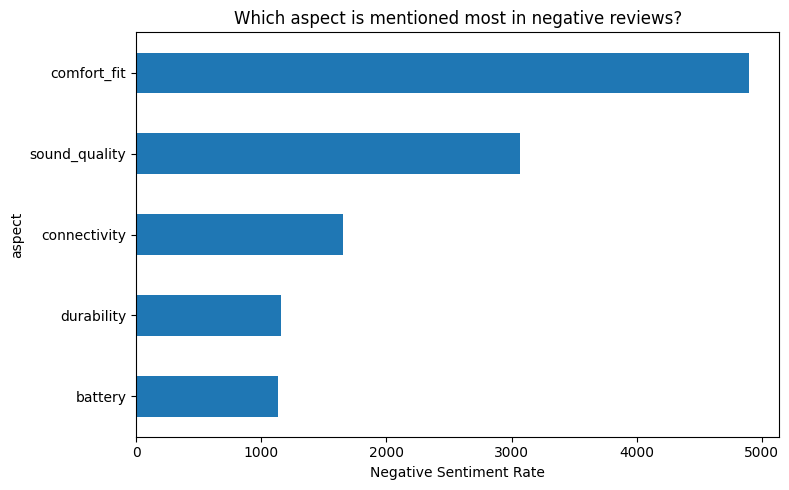

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Sort by mention_count before plotting
aspect_summary_sorted = aspect_summary.sort_values('mention_count', ascending=False)

aspect_summary_sorted['mention_count'].plot(kind='barh')
plt.gca().invert_yaxis()
plt.xlabel('Negative Sentiment Rate')
plt.title('Which aspect is mentioned most in negative reviews?')
plt.tight_layout()
plt.show()

#6. Save Results

In [32]:
aspect_df.to_csv(f'{out_dir}/aspect_sentiment_results.csv', index=False)
aspect_summary.to_csv(f'{out_dir}/aspect_sentiment_summary.csv')

print('Saved. Download both CSVs from Drive into your local data/processed/ folder too.')

Saved. Download both CSVs from Drive into your local data/processed/ folder too.


# Notes
- In this I got know the biggest negative factor for customers in the earbuds review that is confort_fit.
- I was expecting sound quality will be the major issue.

# Future Imporvements
- I will fine-tune DistilBERT on a manually labelled subset of these aspecct-sentences instead of relying only on the pretrained models